In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

In [ ]:
### Import saliency maps
dataset_name = "GENEEG"
saliency_maps_dir = f"results/saliency_maps/{dataset_name}"
print(os.listdir(saliency_maps_dir))  # Check the contents of the directory

saliency_maps = []
for filename in os.listdir(saliency_maps_dir):
    if filename.endswith(".npy"):
        saliency_map = np.load(os.path.join(saliency_maps_dir, filename))
        saliency_maps.append(saliency_map)
#saliency_maps = np.array(saliency_maps)  # Shape: (num_samples, num_channels, num_timepoints)
print(f"Loaded {len(saliency_maps)} saliency maps with shape {saliency_maps[0].shape}")

### Compute power spectral density (PSD) for each saliency map per band
bands = {
        'delta': [0, 4], 
        'theta': [4, 8], 
        'alpha': [8, 12],
        'beta': [12, 30], 
        'gamma': [30, 45]
    }
welch_saliency_maps = []
for saliency_map in saliency_maps[0]:
    print(f"The shape of the saliency map is {saliency_map.shape}")
    freqs, psd = welch(
        saliency_map,
        fs=200,
        axis=1,
        nperseg=200,
        noverlap=100
    )
    psd = psd / (psd.sum() + 1e-8)  # Normalize PSD
    band_psd_sub = []
    for band in bands:
        fmin, fmax = bands[band]
        if band == 'all':
            band_mask = (freqs >= fmin) & (freqs <= fmax)
        else:
            band_mask = (freqs >= fmin) & (freqs < fmax)
        band_psd_sub.append(psd[:, band_mask].sum(axis=1))
    welch_saliency_maps.append(np.array(band_psd_sub).T)  # Shape: (num_channels, num_bands)
welch_saliency_maps = np.array(welch_saliency_maps)  # Shape: (num_samples, num_channels, num_bands)
print(f"Computed Welch PSD for {len(welch_saliency_maps)} saliency maps with shape {welch_saliency_maps[0].shape}")
print(welch_saliency_maps.shape)

['MCIvsHC_MCI vs HC_SCCNet_iteration_1_saliency_maps.npy']
Loaded 1 saliency maps with shape (14, 19, 800)
The shape of the saliency map is (19, 800)
The shape of the saliency map is (19, 800)
The shape of the saliency map is (19, 800)
The shape of the saliency map is (19, 800)
The shape of the saliency map is (19, 800)
The shape of the saliency map is (19, 800)
The shape of the saliency map is (19, 800)
The shape of the saliency map is (19, 800)
The shape of the saliency map is (19, 800)
The shape of the saliency map is (19, 800)
The shape of the saliency map is (19, 800)
The shape of the saliency map is (19, 800)
The shape of the saliency map is (19, 800)
The shape of the saliency map is (19, 800)
Computed Welch PSD for 14 saliency maps with shape (19, 5)
(14, 19, 5)


Flat saliency maps shape: (14, 95)


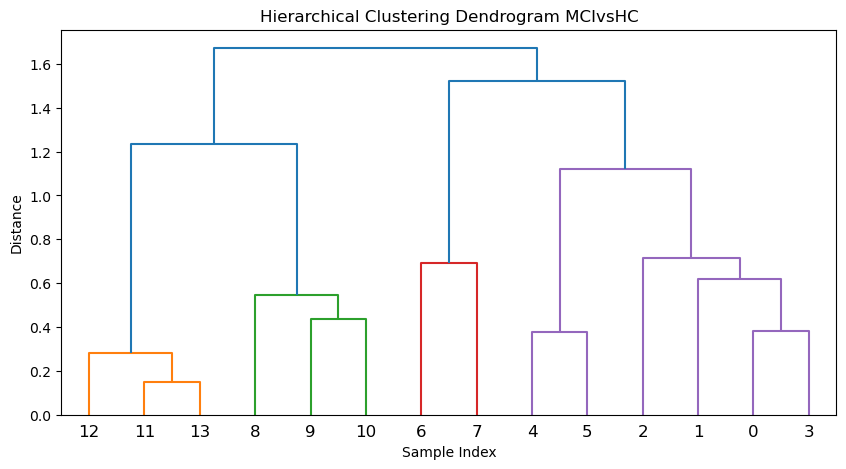

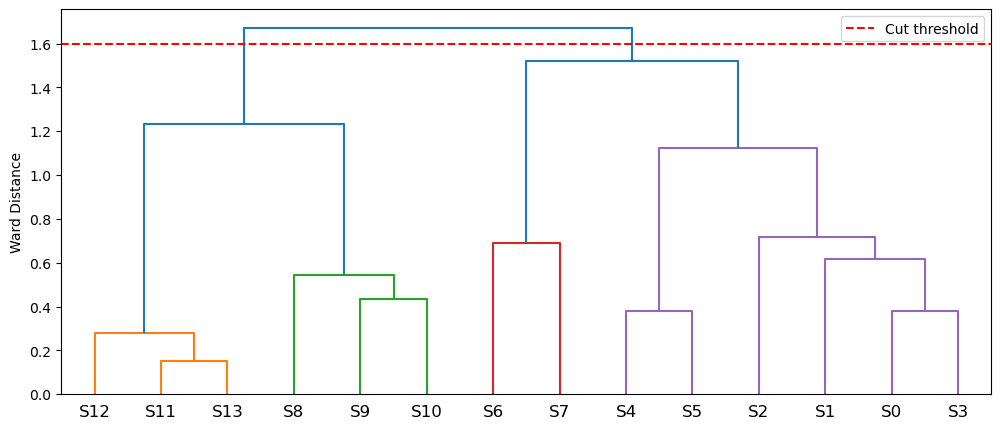

In [9]:
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
scaler2 = RobustScaler()
pca = PCA(n_components=0.9)

flat_saliency_maps = welch_saliency_maps.reshape(welch_saliency_maps.shape[0], -1)
print(f"Flat saliency maps shape: {flat_saliency_maps.shape}")
normalized_saliency_maps = normalize(flat_saliency_maps, norm='l2')
#scaled_saliency_maps = scaler2.fit_transform(flat_saliency_maps)
# print(f"Scaled saliency maps shape: {normalized_saliency_maps.shape}")
#reduced_saliency_maps = pca.fit_transform(normalized_saliency_maps)

Z = linkage(normalized_saliency_maps, method='ward', metric='euclidean')
labels = fcluster(Z, t=1.6, criterion='distance')

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title(f'Hierarchical Clustering Dendrogram {dataset_name}')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

plt.figure(figsize=(12, 5))
dendrogram(Z, labels=[f"S{i}" for i in range(len(normalized_saliency_maps))])
plt.axhline(y=1.6, color='red', linestyle='--', label='Cut threshold')
plt.ylabel("Ward Distance")
plt.legend()
plt.show()

####

/opt/anaconda3/envs/MCI/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


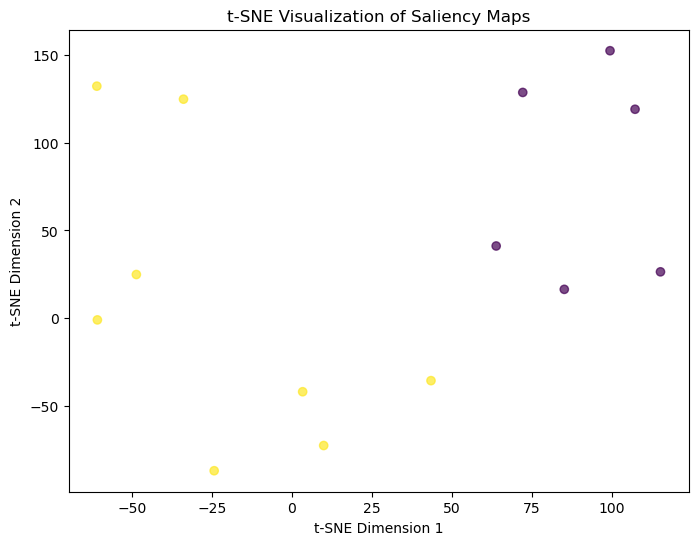

In [8]:
#t-sne visualization
#color the points based on their cluster labels (if you have them)
#need legend for the colors
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=5, n_iter=3000)
tsne_results = tsne.fit_transform(normalized_saliency_maps)
plt.figure(figsize=(8, 6))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, alpha=0.7)
plt.title('t-SNE Visualization of Saliency Maps')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

/opt/anaconda3/envs/MCI/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


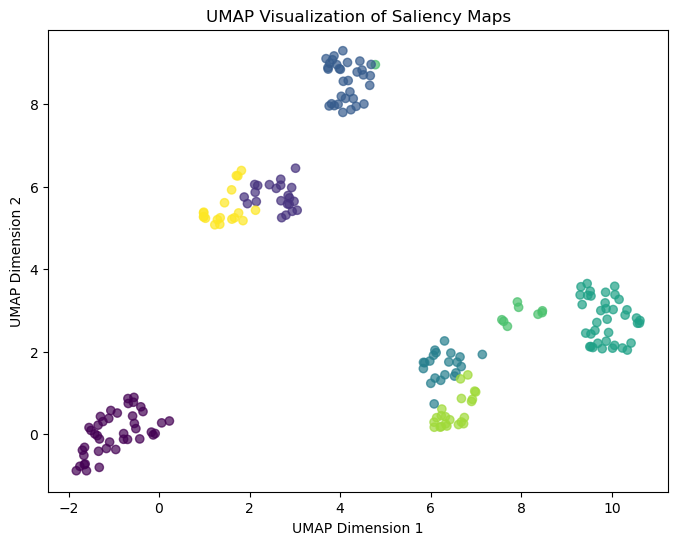

In [68]:
#UMAP visualization
import umap
reducer = umap.UMAP(n_components=2, random_state=42)
umap_results = reducer.fit_transform(reduced_saliency_maps)
plt.figure(figsize=(8, 6))
plt.scatter(umap_results[:, 0], umap_results[:, 1], c=cluster_labels, alpha=0.7)
plt.title('UMAP Visualization of Saliency Maps')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.show()